Problem Statement (Business Understanding)

We will build a Neural Network from scratch (using NumPy + later Keras) to solve a Churn Prediction problem.

Question: Will a bank customer leave the bank (Churn = 1) or stay (Churn = 0)?

This is a Binary Classification problem.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Numerical computation
import numpy as np


# Data handling
import pandas as pd


# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


# Model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [16]:
df=pd.read_csv('/content/drive/MyDrive/AIA/1_Churn_Modelling.csv')

In [17]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
# Shape of data (rows, columns)
df.shape

(10000, 14)

In [19]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [20]:
# Statistical summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [21]:
## missing values check
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [22]:
#Drop Irrelevant Columns
#These columns do not help in prediction:
#CustomerId, RowNumber, Surname
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [23]:
#Encode Categorical Features
# Label Encoding for Gender
gender_encoder = LabelEncoder()
df['Gender'] = gender_encoder.fit_transform(df['Gender'])


# One-Hot Encoding for Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [24]:
# Input features
X = df.drop('Exited', axis=1)


# Target variable
y = df['Exited']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
)

In [26]:
#Feature Scaling (Very Important for Neural Networks)
#Neural networks converge faster when data is scaled.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Create Sequential model
model = Sequential()

# Hidden Layer 1
model.add(Dense(
    units=16,
    activation='relu',
    kernel_initializer='he_uniform',   # Best initializer for ReLU
    input_shape=(X_train.shape[1],)
))

# Hidden Layer 2
model.add(Dense(
    units=8,
    activation='relu',
    kernel_initializer='he_uniform'    # Again ReLU → He initialization
))

# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid',              # Binary classification
    kernel_initializer='glorot_uniform' # Best for sigmoid
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compile the code
model.compile(
optimizer=Adam(learning_rate=0.001),
loss='binary_crossentropy',
metrics=['accuracy']
)

In [31]:
# Train the model
history = history = model.fit(
X_train, y_train,
epochs=50,
batch_size=32,
validation_split=0.2,
verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5404 - loss: 0.7499 - val_accuracy: 0.8037 - val_loss: 0.4908
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7996 - loss: 0.4799 - val_accuracy: 0.8106 - val_loss: 0.4478
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8114 - loss: 0.4464 - val_accuracy: 0.8156 - val_loss: 0.4295
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8105 - loss: 0.4271 - val_accuracy: 0.8238 - val_loss: 0.4141
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8219 - loss: 0.4097 - val_accuracy: 0.8244 - val_loss: 0.3963
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8276 - loss: 0.3916 - val_accuracy: 0.8338 - val_loss: 0.3826
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8383 - loss: 0.3748 - val_accuracy: 0.8375 - val_loss: 0.3735
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8418 - loss: 0.3615 - val_accuracy: 0.

In [32]:
# Predict probabilities
y_prob = model.predict(X_test)


# Convert probabilities to class labels
y_pred = (y_prob > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]])

In [34]:
# evaluate the model
accuracy = model.evaluate(X_test, y_test)
accuracy

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8539 - loss: 0.3527


[0.3529253304004669, 0.8519999980926514]

In [35]:
# list all data in history
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [37]:
history.history

{'accuracy': [0.6798437237739563,
  0.8042187690734863,
  0.8090624809265137,
  0.8137500286102295,
  0.8235937356948853,
  0.8315625190734863,
  0.8409374952316284,
  0.8435937762260437,
  0.8454687595367432,
  0.8485937714576721,
  0.8504687547683716,
  0.8517187237739563,
  0.8532812595367432,
  0.8526562452316284,
  0.8557812571525574,
  0.8568750023841858,
  0.8564062714576721,
  0.856249988079071,
  0.8565624952316284,
  0.8575000166893005,
  0.8553125262260437,
  0.8578125238418579,
  0.8567187786102295,
  0.858593761920929,
  0.8582812547683716,
  0.860156238079071,
  0.858593761920929,
  0.8598437309265137,
  0.859375,
  0.8600000143051147,
  0.8600000143051147,
  0.8596875071525574,
  0.8590624928474426,
  0.859375,
  0.8614062666893005,
  0.862500011920929,
  0.8600000143051147,
  0.8639062643051147,
  0.8604687452316284,
  0.8614062666893005,
  0.8606250286102295,
  0.8596875071525574,
  0.8620312213897705,
  0.8621875047683716,
  0.8626562356948853,
  0.8617187738418579,
 

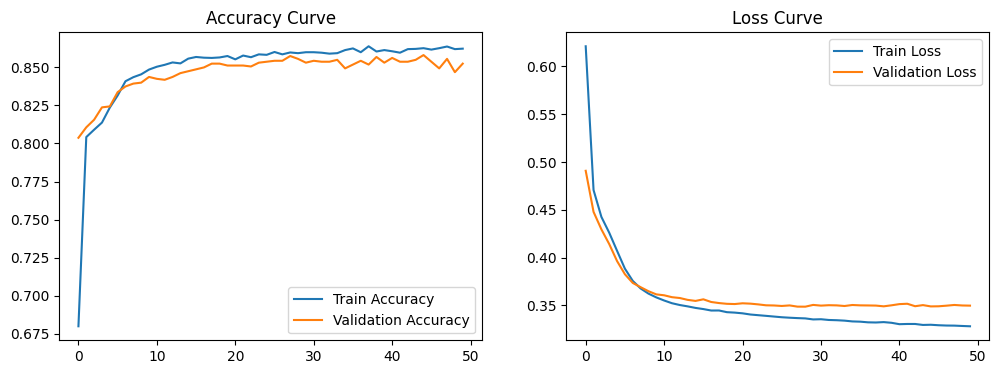

In [38]:
#Visualise the training performance
plt.figure(figsize=(12,4))


# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curve')


# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curve')


plt.show()

In [39]:
#Performance metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.852
Confusion Matrix:
 [[1515   92]
 [ 204  189]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91      1607
           1       0.67      0.48      0.56       393

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000

